## Conjunto de Datos

* ABV: La cantidad de alcohol x volumen
* IBU: El nivel de amargor de la bebida
* Brewery: Cerveceria


In [ ]:
import pandas as pd

datos_cervezas = pd.ExcelFile('/content/drive/MyDrive/Curso Estadistica con Python/Craft Beers.xlsx').parse(
    sheet_name='beers',header=0, index_col=False)
datos_cervezas.head()

,abv,ibu,id,name,style,brewery_id,ounces
0,0.050,NaN,1436,Pub Beer,American Pale Lager,408,12.0
1,0.066,NaN,2265,Devil's Cup,American Pale Ale (APA),177,12.0
2,0.071,NaN,2264,Rise of the Phoenix,American IPA,177,12.0
3,0.090,NaN,2263,Sinister,American Double / Imperial IPA,177,12.0
4,0.075,NaN,2262,Sex and Candy,American IPA,177,12.0


In [ ]:
datos_cervecerias = pd.ExcelFile('/content/drive/MyDrive/Curso Estadistica con Python/Craft Beers.xlsx').parse(
    sheet_name='brewery',header=0, index_col=False)
datos_cervecerias.head()

,name,city,state,id
0,NorthGate Brewing,Minneapolis,MN,0
1,Against the Grain Brewery,Louisville,KY,1
2,Jack's Abby Craft Lagers,Framingham,MA,2
3,Mike Hess Brewing Company,San Diego,CA,3
4,Fort Point Beer Company,San Francisco,CA,4


In [ ]:
datos = pd.merge(datos_cervezas,
                 datos_cervecerias,
                 how = 'left',
                 left_on='brewery_id',
                 right_on='id',
                 sort = True,
                 suffixes = ('_cervezas', '_cervecerias')
                 )
datos.head()

,abv,ibu,id_cervezas,name_cervezas,style,brewery_id,ounces,name_cervecerias,city,state,id_cervecerias
0,0.045,50.0,2692,Get Together,American IPA,0,16.0,NorthGate Brewing,Minneapolis,MN,0
1,0.049,26.0,2691,Maggie's Leap,Milk / Sweet Stout,0,16.0,NorthGate Brewing,Minneapolis,MN,0
2,0.048,19.0,2690,Wall's End,English Brown Ale,0,16.0,NorthGate Brewing,Minneapolis,MN,0
3,0.060,38.0,2689,Pumpion,Pumpkin Ale,0,16.0,NorthGate Brewing,Minneapolis,MN,0
4,0.060,25.0,2688,Stronghold,American Porter,0,16.0,NorthGate Brewing,Minneapolis,MN,0


## Medidas de Tendencia Central

* Media
* Mediana
* Moda


In [ ]:
# Media

print('El valor de la media ibu: ', round(datos['ibu'].mean(),2))

El valor de la media ibu:  42.71


In [ ]:
# Mediana

print('El valor de la mediana ibu: ', datos['ibu'].median())

El valor de la mediana ibu:  35.0


In [ ]:
# Moda

print('El valor de la moda ibu: ', datos['ibu'].mode())

#el 0 significa el indice, posición 0

El valor de la moda ibu:  0    20.0
Name: ibu, dtype: float64


## Medidas de Dispersión

* Varianza

* Desviación Estandar

In [ ]:
#Varianza

print('El valor de la varianza ibu: ', round(datos['ibu'].var(),2))

El valor de la varianza ibu:  673.61


In [ ]:
# Desviacion estandar

print('El valor de la desviacion estandar ibu: ', round(datos['ibu'].std(),2))

El valor de la desviacion estandar ibu:  25.95


## Medidas de Rango

* minimo
* maximo
* rango

In [ ]:
# Minimo

print('El valor del minimo ibu: ', datos['ibu'].min())

El valor del minimo ibu:  4.0


In [ ]:
# Maximo

print('El valor del maximo ibu: ', datos['ibu'].max())

El valor del maximo ibu:  138.0


In [ ]:
# Rango

print('El valor del rango ibu: ', datos['ibu'].max() - datos['ibu'].min())

El valor del rango ibu:  134.0


## Medidas de Cuantiles

* Percentiles
* Cuartiles
* Quintiles

In [ ]:
# Percentil

print('El valor del percentil 75 ibu: ', datos['ibu'].quantile(0.75))

El valor del percentil 75 ibu:  64.0


In [ ]:
# Cuartiles

print('El valor del primer cuartil ibu: ', datos['ibu'].quantile(0.25))

El valor del primer cuartil ibu:  21.0


In [ ]:
# Quintil

print('El valor del quintil 3 ibu: ', datos['ibu'].quantile(0.4))

El valor del quintil 3 ibu:  30.0


##Covariaza

In [ ]:
# covarianza

covarianza = datos['ibu'].cov(datos['abv'])
print('La covarianza entre ibu y abv es: ', covarianza)

La covarianza entre ibu y abv es:  0.2363007786598534


In [ ]:
datos_numericos = datos.select_dtypes(include='number')

In [ ]:
# Covarianza matrix

cov_matriz = datos_numericos.cov()
cov_matriz

,abv,ibu,id_cervezas,brewery_id,ounces,id_cervecerias
abv,0.000183,0.236301,0.434019,-0.208618,0.005450,-0.208618
ibu,0.236301,673.613537,9.539807,-19.023463,3.198340,-19.023463
id_cervezas,0.434019,9.539807,566196.013315,-59804.216975,178.486724,-59804.216975
brewery_id,-0.208618,-19.023463,-59804.216975,24864.749741,-49.613358,24864.749741
ounces,0.005450,3.198340,178.486724,-49.613358,5.532862,-49.613358
id_cervecerias,-0.208618,-19.023463,-59804.216975,24864.749741,-49.613358,24864.749741


In [ ]:
#sin la necesidad de filtrar numericos

cov_matriz2 = datos.cov(numeric_only=True)
cov_matriz2

,abv,ibu,id_cervezas,brewery_id,ounces,id_cervecerias
abv,0.000183,0.236301,0.434019,-0.208618,0.005450,-0.208618
ibu,0.236301,673.613537,9.539807,-19.023463,3.198340,-19.023463
id_cervezas,0.434019,9.539807,566196.013315,-59804.216975,178.486724,-59804.216975
brewery_id,-0.208618,-19.023463,-59804.216975,24864.749741,-49.613358,24864.749741
ounces,0.005450,3.198340,178.486724,-49.613358,5.532862,-49.613358
id_cervecerias,-0.208618,-19.023463,-59804.216975,24864.749741,-49.613358,24864.749741


## Corelacion

* entre -1 y 1
* pearson
* alto positivo mayor a 0.7

causa: fumar, cancer

correlacion: consumo café, alto estrés  /
             guardavidas, ahogamientos

* diferenciar coincidencia con correlacion




In [ ]:
datos[['ibu','abv','ounces']].corr() ##por defecto es pearson

,ibu,abv,ounces
ibu,1.000000,0.670621,0.054691
abv,0.670621,1.000000,0.172529
ounces,0.054691,0.172529,1.000000


In [ ]:
datos[['ibu','abv','ounces']].cov()

,ibu,abv,ounces
ibu,673.613537,0.236301,3.198340
abv,0.236301,0.000183,0.005450
ounces,3.198340,0.005450,5.532862


Cual usar:

Supuestos:

* Pearson ,debe tener correlacion lineal clara, datos normales (prueba de normalidad), no deben haber valores extremos, datos deben ser continuos (no discretos)

* Spearman, ve la relación monótona. Utiliza rangos en vez de los valores originales. Entre -1 y 1. Relacion perfecto monótona creciente. Se utilizan cuando no hay relación normal ni normales. Deben tener siempre un valor creciente o decreciente. No es tan sensible a los valores atípicos. Útil para datos ordinales

* Tau Kendall, concordantes: ambos suben o bajan. discordante: una sube otro baja. Funciona si tiene valores muy atípicos, no es tan sensible. Set de datos pequeños. Mide monótonas. Variables ordinales o continuas.






In [ ]:
datos[['ibu','abv','ounces']].corr(method = 'kendall')

,ibu,abv,ounces
ibu,1.000000,0.498390,0.044995
abv,0.498390,1.000000,0.142884
ounces,0.044995,0.142884,1.000000


In [ ]:
datos[['ibu','abv','ounces']].corr(method = 'spearman')

,ibu,abv,ounces
ibu,1.000000,0.667780,0.054958
abv,0.667780,1.000000,0.173042
ounces,0.054958,0.173042,1.000000


Historigrama

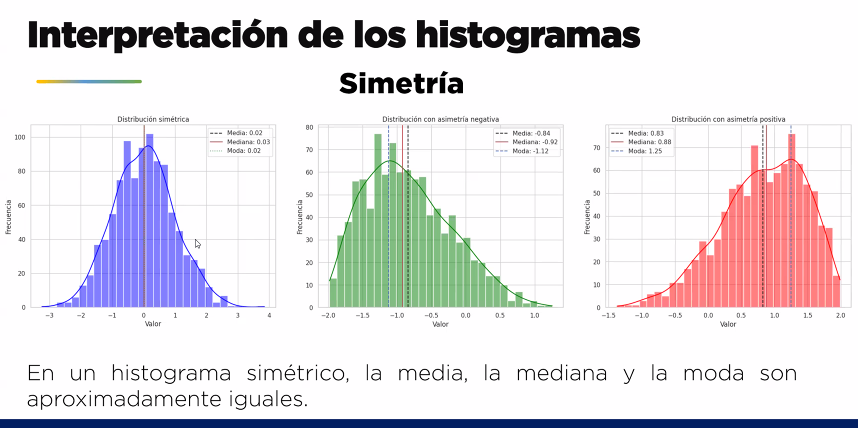

* importante, la verde es asimetria positiva, y la roja es asimetria negativa

* para realizar un relación lineal, se utilizaría el gráfico azul, que es está normal

* Se estudia variable por variable

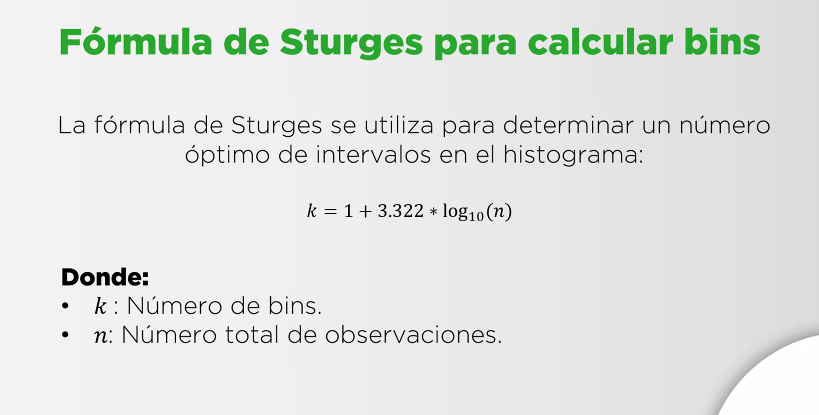

Solo se utiliza con muestras, no con datos de big data